# Chapter 3 — Why not: the thin edge

Chapters 1–2 established *what* happens: the learned bettor converges to ≈ Flat and never holds Kelly.
This chapter is *why*. The answer is not a training bug — a **positive control** (below) shows the same
network learns Kelly cleanly on a denoised signal, and Chapter 4 rules the representational suspect out —
it is the **signal itself**. Four facts, each with a figure:

1. **The prize is tiny.** The entire growth advantage Kelly buys over Flat is ~**0.10 × 10⁻⁴ per hand** —
   and even that leaves Kelly *net-negative* (it loses *less* than Flat, not money).
2. **It is sub-noise.** That edge lives inside a per-hand payoff whose SD is ~**1.15** — even at the
   max-bet counts the per-count edge is ~**2% of one standard deviation**, so a value learner estimates
   it *through* far larger noise.
3. **The ramps it visits are worse than Flat.** The orbit *does* pass through near-Kelly curves — but
   measured on the four axes, those best checkpoints are *far* riskier than flat (deep-drawdown **14–18%**
   vs ~0.8%) and **no better on growth**. They are over-betting excursions, not better policies.
4. **Coverage.** The states that matter — high counts — are rare, so the agent barely trains on them
   (the betting analog of Problem-A's rarely-visited cells).

In [1]:
import sys; sys.path.insert(0, '.')
from blackjack_rl.analysis_loader import (
    load_bet_runs, load_bet_evals, bet_provenance, ladder_provenance, oracle_run, near_kelly_runs,
    plot_prize_bar, plot_signal_vs_noise, plot_kelly_distance, plot_ladder_bars, plot_native_curves,
    plot_bet_orbit, plot_count_frequency,
)

runs = load_bet_runs()
evals = load_bet_evals()
AGENT_CFG = {"growth": {"bankroll_feature": "raw"}, "ruin": {"gamma": 0.95, "double": "off"}}

# audited constants (edge reference): base edge ~0.54%/hand, per-hand reward SD ~1.15; the bettor's real
# signal is the per-count edge (up to ~+2.5% at the richest counts — still sub-noise, and rarest where big)
BASIC_EDGE_PER_HAND = 0.0054
HIGH_COUNT_EDGE = 0.0246      # edge at TC +6, the first count Kelly bets the max on
PER_HAND_REWARD_SD = 1.15

### First, a positive control — the pipeline *can* learn Kelly

Before blaming the signal, rule out the method. The **oracle** run keeps the same network, replay buffer
and encode → Q → argmax pipeline, at the growth bettor's γ = 0, and swaps each hand's *realised* log-reward
for its **noise-free expectation** from the measured edge curve (rescaled to O(1)). It runs on the plain
baseline knobs — batch 128, constant lr, not the tuned real-reward recipe: with the noise gone, the
noise-averaging machinery (big batches, decaying lr) shouldn't be needed — and isn't. If the flatline were
a bug, a weak architecture, or an optimisation failure, the oracle would flatten too. It doesn't — it locks
a clean, stable Kelly ramp:

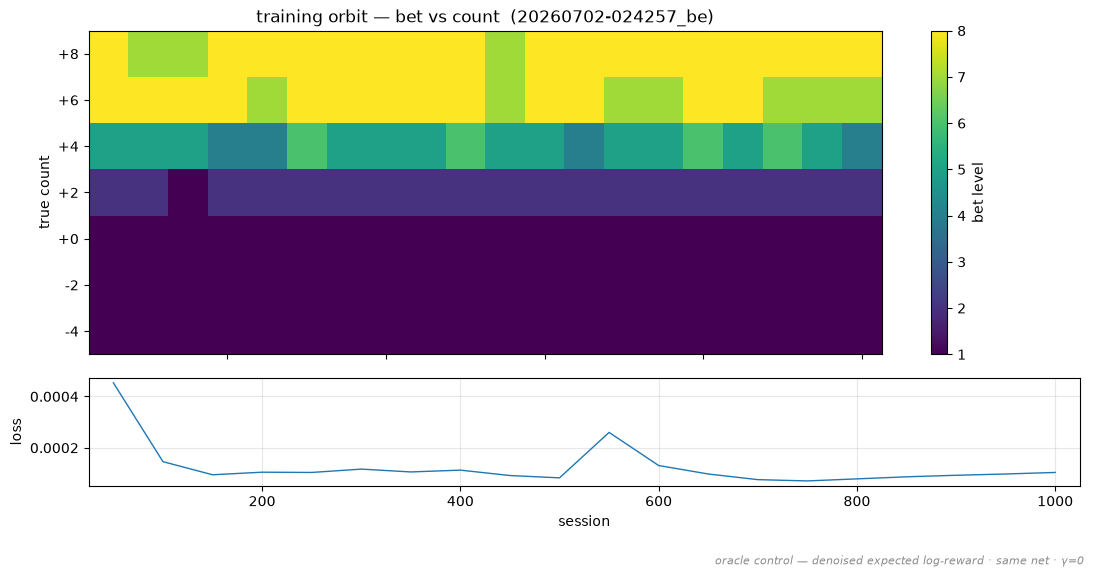

In [2]:
plot_bet_orbit(oracle_run(), note="oracle control — denoised expected log-reward · same net · γ=0")

Low counts hold the minimum, the high counts ramp to the Kelly levels, and — unlike every real-reward
orbit (Chapter 2's, and §3.4's growth runs alike) — it **stays there** (the loss falls monotonically as
the ramp settles). Same network and pipeline; the decisive change is the noise-free reward. So the
encode → Q → argmax → bet pipeline is sound and the network
*can* represent and hold the ramp — what defeats it on real reward is the noise and coverage of §3.2–3.4,
not the method.

## 3.1 The prize is tiny

Everything a learner could win here is the gap between the two baselines. In the growth regime, Kelly's
growth clears Flat's by only about **0.10 × 10⁻⁴ per hand** (independent-sample z ≈ 7 on the tight 20k
measurement) — and even that leaves Kelly **net-negative**: both bettors lose to the table-minimum tax,
Kelly just loses *less*. That vanishing gap is the whole reward for perfect count-based bet-sizing, and a
learner that captures none of it lands exactly where the BetAgent does — at Flat.

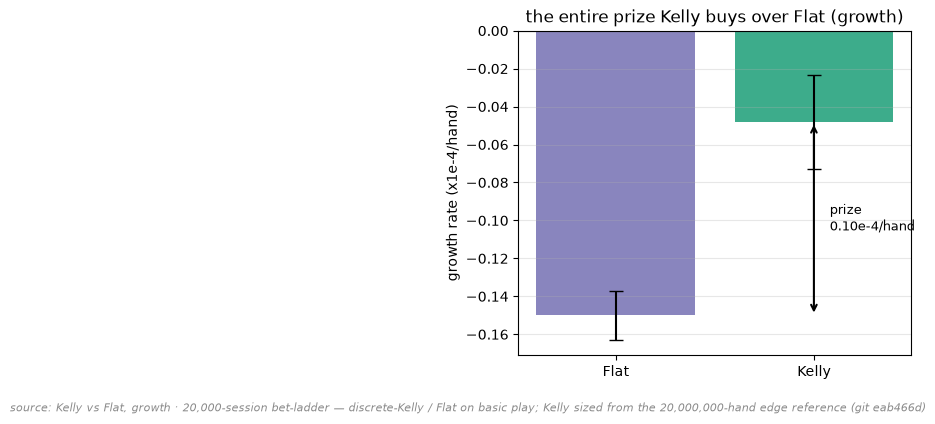

In [3]:
plot_prize_bar(regime="growth", note=ladder_provenance(role="Kelly vs Flat, growth"))

## 3.2 …and it is sub-noise

Why can't a DQN just estimate the edge? Because it must estimate it *through* the per-hand payoff, and that
payoff is far noisier than the edge. Basic strategy loses ~0.54%/hand on average, but the bettor cares about
the edge **at each count** — from about **−0.3% at neutral to ~+2.5% at TC +6** (where Kelly first bets the
max; the rarer +8 is richer still). A single hand's reward has a standard deviation of ~**1.15**, so even that max-bet
edge is only ~**2% of one standard deviation**. Telling a rich count apart from a neutral one
therefore takes an enormous sample — and §3.4 shows the richest counts are exactly the **rarest**.

The schematic below draws the per-hand reward at a favorable count against the no-edge baseline. They are,
for all practical purposes, the same curve — the signal the value learner must resolve is buried in the
per-hand noise.

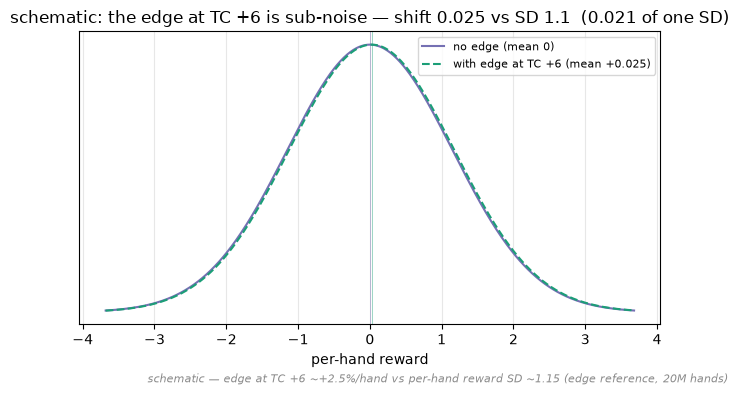

In [4]:
plot_signal_vs_noise(HIGH_COUNT_EDGE, PER_HAND_REWARD_SD, signal_label="edge at TC +6",
                     note="schematic — edge at TC +6 ~+2.5%/hand vs per-hand reward SD ~1.15 (edge reference, 20M hands)")

## 3.3 The orbit *visits* Kelly — but the visited ramps are worse than Flat

A natural hope: maybe the agent finds a good ramp mid-training and the *final* policy just drifts off it —
so the "best checkpoint" is the real prize. The distance-to-Kelly trace shows those visits happen (the
dips). But when we take each run's **best ramp checkpoint** and measure it on the four axes, the hope dies.

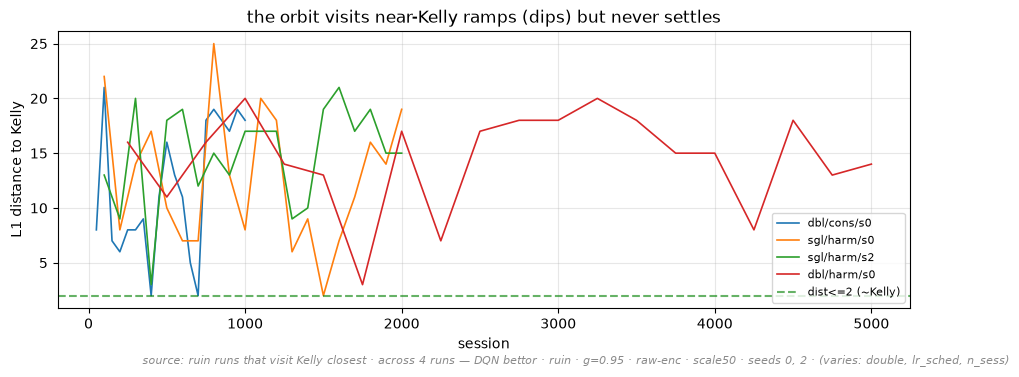

In [5]:
near_kelly = near_kelly_runs("ruin", 4)   # the runs whose orbit dips CLOSEST to Kelly (dist 2-3)
plot_kelly_distance(near_kelly, label=lambda r: f"{'dbl' if r.double else 'sgl'}/{r.lr_sched[:4]}/s{r.seed}",
                    note=bet_provenance(near_kelly, role="ruin runs that visit Kelly closest"))

Best-checkpoint vs Flat, on the two axes that matter. The decisive axis is **drawdown**: in the ruin regime
the visited ramps breach the half-bankroll mark **14–18%** of the time versus Flat's ~0.8%, and they are
**no better on growth** (wide spread, overlapping Flat's). The growth regime repeats the story — deep-
drawdown ~5% versus Flat's 0, and growth *decisively* worse (−0.52 ± 0.23 vs −0.15, z ≈ 5). They *look*
like Kelly at a single-count probe but over-bet in the full policy — the recurring trap of Chapter 1. The
"best ramp" is not a better policy; it is an over-betting excursion the objective correctly declines to
keep. (Each is its run's
*closest-to-Kelly* checkpoint — selected by shape, not by performance — so this is an honest "is the ramp
real?" probe, not cherry-picking.)

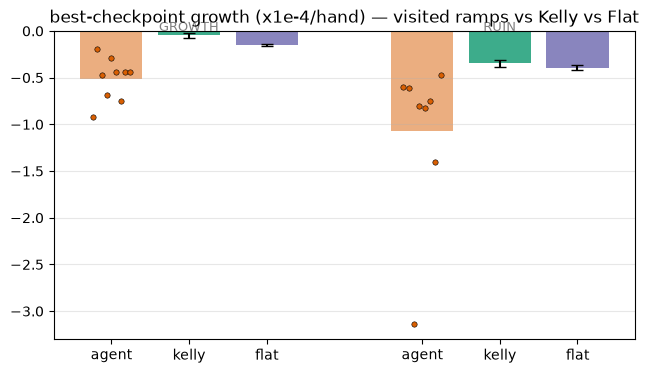

In [6]:
plot_ladder_bars(evals, "growth_1e4", AGENT_CFG, phase="best-ckpt", title="best-checkpoint growth (x1e-4/hand) — visited ramps vs Kelly vs Flat")

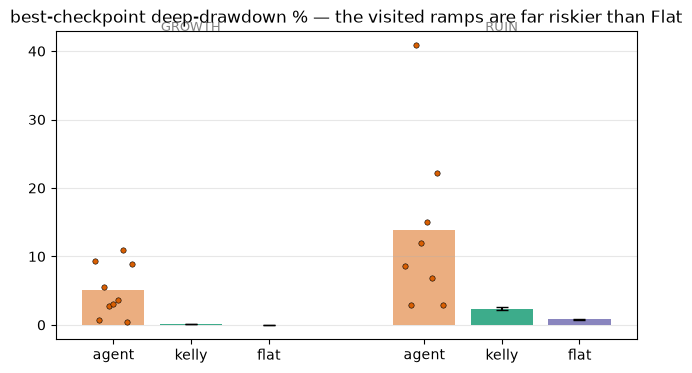

In [7]:
plot_ladder_bars(evals, "dd_pct", AGENT_CFG, phase="best-ckpt", title="best-checkpoint deep-drawdown % — the visited ramps are far riskier than Flat")

## 3.4 Coverage — the states that matter are rare

The last piece is *why the estimate never sharpens where it counts*. High true counts — where the edge (and
the whole case for betting more) lives — are **rare**: the shoe spends most of its life near neutral. The
20M-hand reference makes it concrete — **TC +6, where Kelly bets 8, is only 0.9% of hands; TC +8 is 0.26%**
— so the agent sees very few high-count hands to average over, and its bet there stays near the minimum.

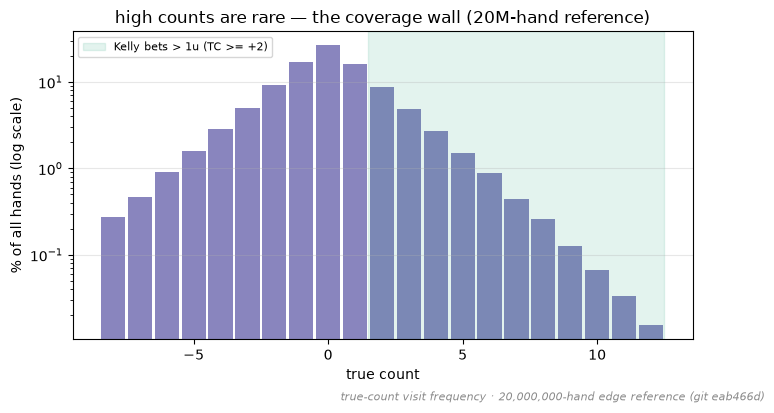

In [8]:
plot_count_frequency(note="true-count visit frequency · 20,000,000-hand edge reference (git eab466d)")

The native bet-vs-count curves confirm it: at high counts they mostly stay flat, or gate only *coarsely
and inconsistently across seeds* — never the clean Kelly ramp. (At low counts the curves sit at ~1, but that
says nothing: Kelly bets the minimum there too, so only the high counts are diagnostic.) It is the betting
analog of Problem-A's rarely-visited hand cells.

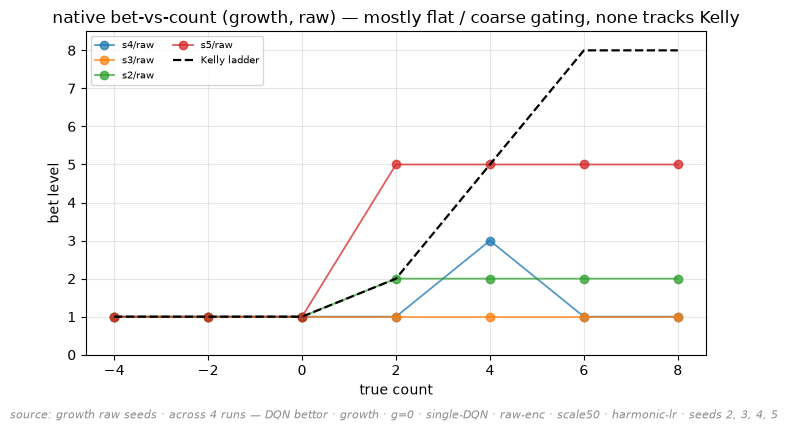

In [9]:
growth_raw = runs[(runs.regime=='growth') & (runs.bankroll_feature=='raw')].tail(4)
plot_native_curves(growth_raw, title="native bet-vs-count (growth, raw) — mostly flat / coarse gating, none tracks Kelly",
                   note=bet_provenance(growth_raw, role="growth raw seeds"))

## 3.5 Reading

Put the four together and "≈ Flat" stops being a disappointment and becomes the *correct* answer for this
signal. The prize is 0.10e-4/hand; it is buried under SD-1.15 noise; the ramps that would claim it are
worse than Flat when measured; and the states that carry the edge are too rare to learn. End-to-end value
learning is the wrong tool here — not because it is weak, but because the signal is thin. Chapter 4 tests
the one remaining escape hatch (*maybe it's the representation*), and closes it.